In [3]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib as plt

import seaborn as sns

Aqui trabajamos con https://archive.ics.uci.edu/dataset/60/liver+disorders

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
liver_disorders = fetch_ucirepo(id=60)

# data (as pandas dataframes)
X = liver_disorders.data.features
y = liver_disorders.data.targets

# metadata
print(liver_disorders.metadata)

# variable information
print(liver_disorders.variables)


{'uci_id': 60, 'name': 'Liver Disorders', 'repository_url': 'https://archive.ics.uci.edu/dataset/60/liver+disorders', 'data_url': 'https://archive.ics.uci.edu/static/public/60/data.csv', 'abstract': 'BUPA Medical Research Ltd. database donated by Richard S. Forsyth', 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 345, 'num_features': 5, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['drinks'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2016, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C54G67', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'The first 5 variables are all blood tests which are thought to be sensitive to liver disorders that might arise from excessive alcohol consumption. Each line in the dataset constitutes the record of a single male individual.\n\nImportant note: The 7

## Recursos

Estamos utilizando el conjunto de datos **'Liver Disorders'** (Trastornos Hepáticos) del repositorio UCI Machine Learning. Aquí hay un resumen de la información clave del conjunto de datos:

*   **ID UCI:** 60
*   **Nombre:** Liver Disorders
*   **URL del Repositorio:** https://archive.ics.uci.edu/dataset/60/liver+disorders
*   **Resumen:** Base de datos de BUPA Medical Research Ltd. donada por Richard S. Forsyth.
*   **Área:** Salud y Medicina
*   **Número de Instancias:** 345
*   **Número de Características:** 5 (variables de análisis de sangre) y 1 variable objetivo ('drinks').
*   **Año de Creación:** 2016

Este dataset contiene mediciones de pruebas sanguíneas que se cree son sensibles a trastornos hepáticos relacionados con el consumo excesivo de alcohol. La variable objetivo es 'drinks', que representa el número de equivalentes de medio litro de bebidas alcohólicas consumidas por día.

In [4]:
import pandas as pd

# Combinar X y y en un solo DataFrame
df_combined = pd.concat([X, y], axis=1)

# Guardar el DataFrame combinado como un archivo CSV
csv_filename = 'liver_disorders_combined.csv'
df_combined.to_csv(csv_filename, index=False)

print(f"El archivo '{csv_filename}' ha sido guardado exitosamente en tu entorno de Colab.")
print("Puedes descargarlo desde el panel de 'Archivos' en el lado izquierdo de Colab.")

El archivo 'liver_disorders_combined.csv' ha sido guardado exitosamente en tu entorno de Colab.
Puedes descargarlo desde el panel de 'Archivos' en el lado izquierdo de Colab.


Este código primero une las columnas de las características (`X`) y la variable objetivo (`y`) en un único DataFrame llamado `df_combined`. Luego, guarda este DataFrame como un archivo CSV llamado `liver_disorders_combined.csv` en la sesión actual de Colab. Puedes encontrar este archivo en el explorador de archivos de Colab y descargarlo a tu máquina local.

In [5]:
# Cargar la base de datos
Liver4 = pd.read_csv("liver_disorders_combined.csv")

In [6]:
Liver4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mcv      345 non-null    int64  
 1   alkphos  345 non-null    int64  
 2   sgpt     345 non-null    int64  
 3   sgot     345 non-null    int64  
 4   gammagt  345 non-null    int64  
 5   drinks   345 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 16.3 KB


In [7]:
Liver4.shape

(345, 6)

Veamos si hay duplicados

In [9]:
Liver4.duplicated().sum()

np.int64(4)

In [10]:
Liver4.duplicated().sum().sum()

np.int64(4)

In [11]:
# Mostrar las filas duplicadas (si existen)
print(Liver4[Liver4.duplicated()])

     mcv  alkphos  sgpt  sgot  gammagt  drinks
85    94       58    21    18       26     2.0
149   91       63    25    26       15     6.0
175   97       71    29    22       52     8.0
317   92       80    10    26       20     6.0


In [12]:
# Eliminar duplicados y dejar solo una copia de cada fila
Liver4 = Liver4.drop_duplicates()

In [13]:
# Verificar nuevamente
print(Liver4.duplicated().sum())

0


In [14]:
print(Liver4.describe())


              mcv     alkphos        sgpt        sgot     gammagt      drinks
count  341.000000  341.000000  341.000000  341.000000  341.000000  341.000000
mean    90.120235   69.891496   30.513196   24.662757   38.401760    3.431085
std      4.452385   18.431988   19.586249   10.115541   39.439379    3.341640
min     65.000000   23.000000    4.000000    5.000000    5.000000    0.000000
25%     87.000000   57.000000   19.000000   19.000000   15.000000    0.500000
50%     90.000000   67.000000   26.000000   23.000000   25.000000    3.000000
75%     92.000000   80.000000   34.000000   27.000000   46.000000    5.000000
max    103.000000  138.000000  155.000000   82.000000  297.000000   20.000000


Buscamos datos atipicos

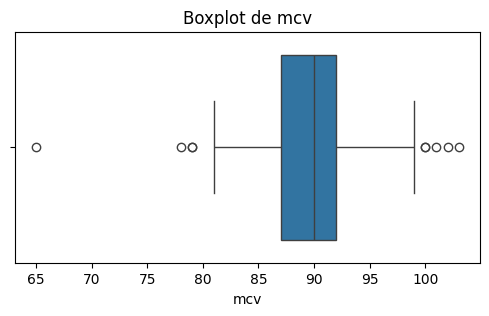

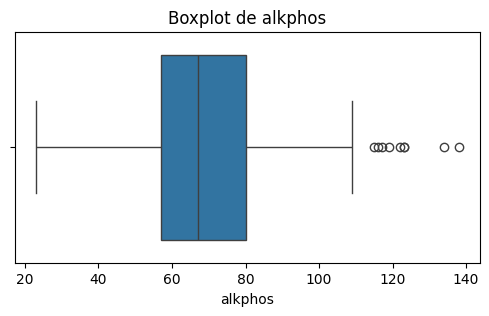

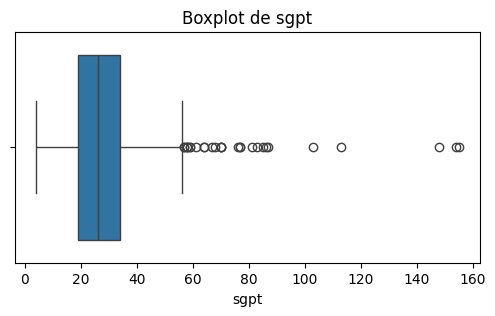

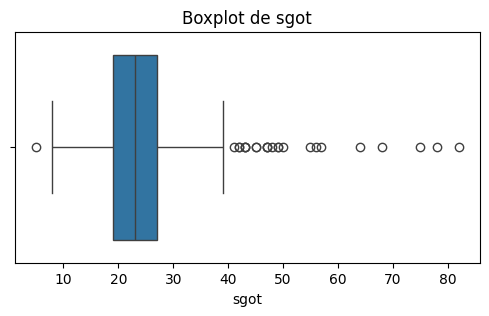

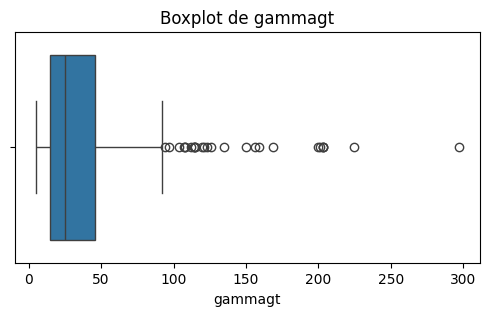

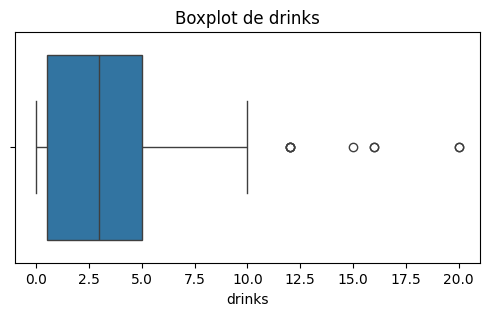

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = Liver4.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=Liver4[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


## Descripción de Columnas del Dataset

| Nombre de Columna | Rol        | Tipo        | Descripción                                                                                               |
| :---------------- | :--------- | :---------- | :-------------------------------------------------------------------------------------------------------- |
| **mcv**           | Feature    | Continuous  | Volumen corpuscular medio.                                                                                |
| **alkphos**       | Feature    | Continuous  | Fosfatasa alcalina.                                                                                       |
| **sgpt**          | Feature    | Continuous  | Alanina aminotransferasa.                                                                                 |
| **sgot**          | Feature    | Continuous  | Aspartato aminotransferasa.                                                                               |
| **gammagt**       | Feature    | Continuous  | Gamma-glutamil transpeptidasa.                                                                            |
| **drinks**        | Target     | Continuous  | Número de equivalentes de medio litro de bebidas alcohólicas consumidas por día.                          |
| **selector**      | Other      | Categorical | Campo creado por los investigadores de BUPA para dividir los datos en conjuntos de entrenamiento/prueba. |


In [19]:
csv_filename_liver4 = 'Liver4_processed.csv'
Liver4.to_csv(csv_filename_liver4, index=False)

print(f"El archivo '{csv_filename_liver4}' ha sido guardado exitosamente en tu entorno de Colab.")
print("Puedes descargarlo desde el panel de 'Archivos' en el lado izquierdo de Colab.")

El archivo 'Liver4_processed.csv' ha sido guardado exitosamente en tu entorno de Colab.
Puedes descargarlo desde el panel de 'Archivos' en el lado izquierdo de Colab.
